#  Phase 8 – Safety Hotspot Analysis & Recommendations

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/RTA Dataset.csv")

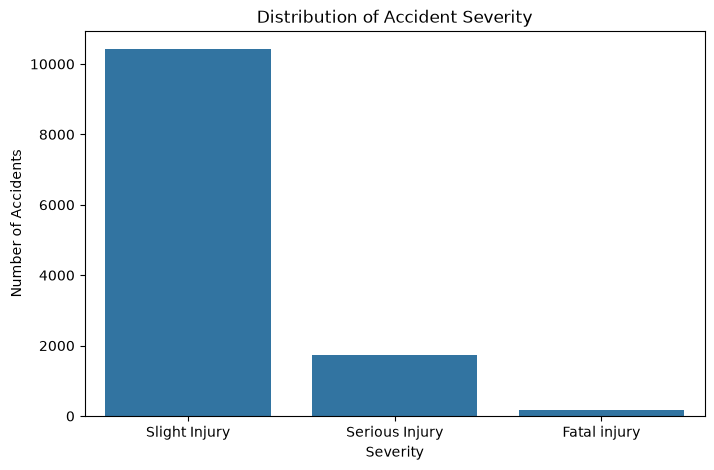

In [4]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Accident_severity",
    order=df["Accident_severity"].value_counts().index
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Severity")
plt.ylabel("Number of Accidents")

plt.show()

Observation : Most accidents belong to the Slight Injury category, while Fatal Injuries occur less frequently but require special attention due to their high impact.

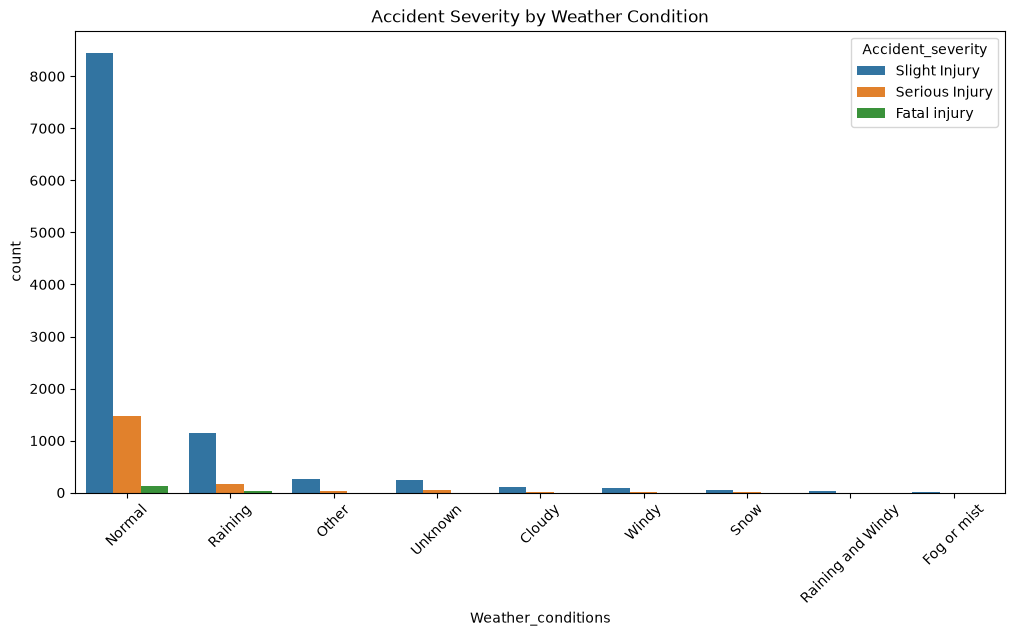

In [5]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Weather_conditions",
    hue="Accident_severity",
    order=df["Weather_conditions"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Accident Severity by Weather Condition")

plt.show()

Observation :
-Most accidents occur during normal weather because more vehicles are on the road.
-Rainy or adverse weather conditions often have a higher proportion of serious accidents.

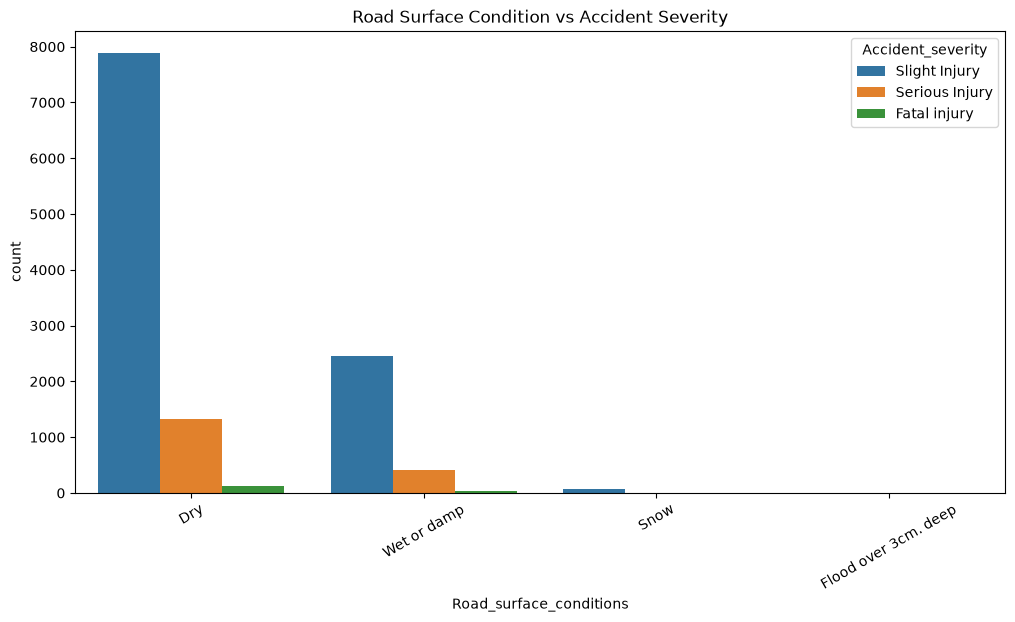

In [6]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="Road_surface_conditions",
    hue="Accident_severity"
)

plt.xticks(rotation=30)

plt.title("Road Surface Condition vs Accident Severity")

plt.show()

Observation : Identify whether wet or dry roads have different accident patterns.

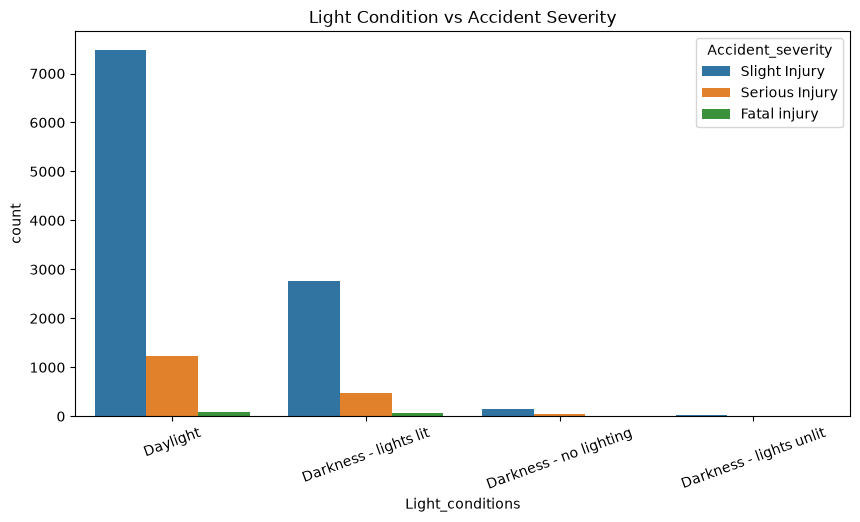

In [7]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Light_conditions",
    hue="Accident_severity"
)

plt.xticks(rotation=20)

plt.title("Light Condition vs Accident Severity")

plt.show()

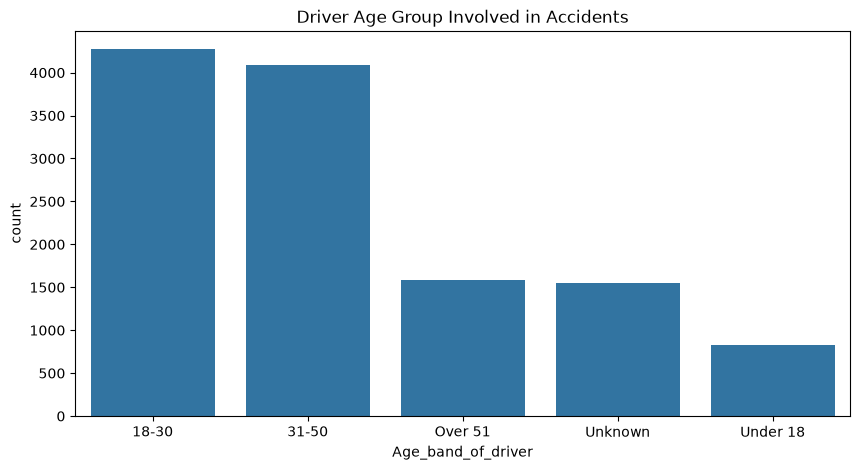

In [8]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Age_band_of_driver",
    order=df["Age_band_of_driver"].value_counts().index
)

plt.title("Driver Age Group Involved in Accidents")

plt.show()

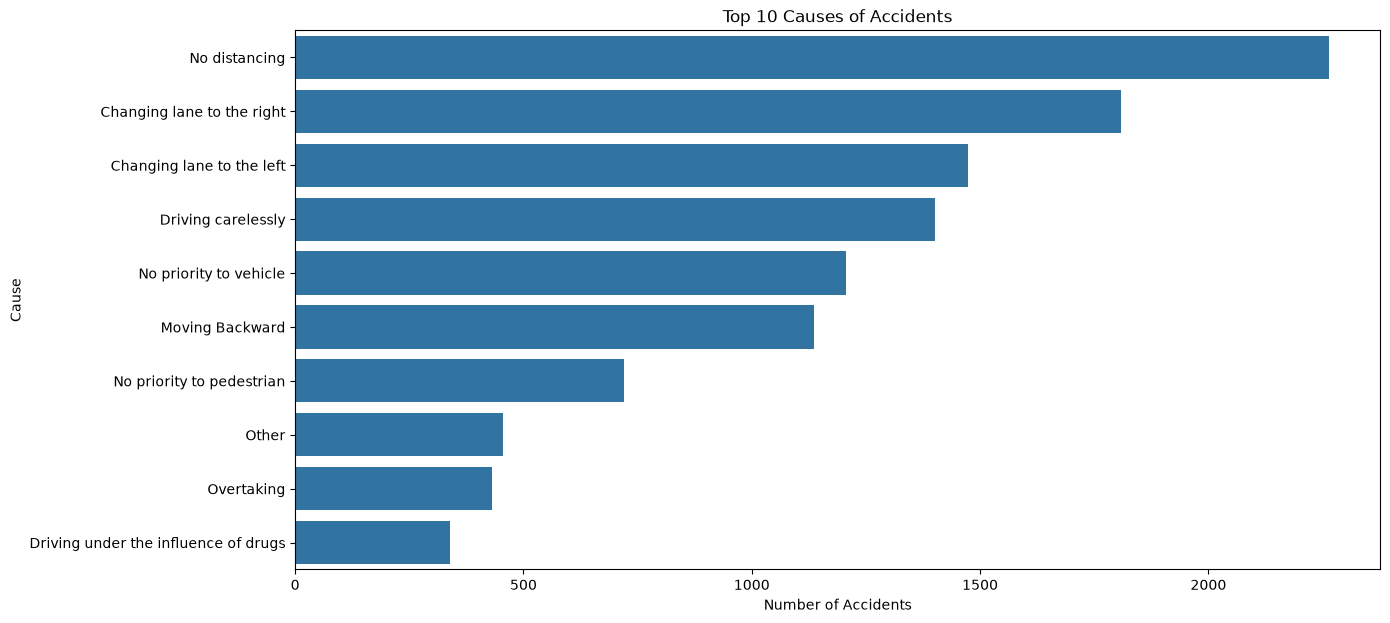

In [9]:
plt.figure(figsize=(14,7))

top_causes = df["Cause_of_accident"].value_counts().head(10)

sns.barplot(
    x=top_causes.values,
    y=top_causes.index
)

plt.title("Top 10 Causes of Accidents")

plt.xlabel("Number of Accidents")

plt.ylabel("Cause")

plt.show()

In [10]:
risk_summary = df.groupby(
    [
        "Weather_conditions",
        "Road_surface_conditions"
    ]
).size().reset_index(name="Number_of_Accidents")

risk_summary.sort_values(
    by="Number_of_Accidents",
    ascending=False
).head(10)

,Weather_conditions,Road_surface_conditions,Number_of_Accidents
4,Normal,Dry,8875
12,Raining,Wet or damp,1312
6,Normal,Wet or damp,1173
18,Unknown,Dry,272
9,Other,Wet or damp,197
21,Windy,Wet or damp,92
7,Other,Dry,86
0,Cloudy,Dry,70
1,Cloudy,Wet or damp,55
16,Snow,Snow,38


In [11]:
recommendations = pd.DataFrame({

    "Risk Factor":[
        "Rainy Weather",
        "Poor Lighting",
        "Driver Inattention",
        "Wet Roads",
        "Young Drivers"
    ],

    "Recommended Action":[
        "Reduce speed limits during rain",
        "Install additional street lights",
        "Increase awareness campaigns",
        "Improve road maintenance",
        "Provide defensive driving training"
    ]
    
})

recommendations

,Risk Factor,Recommended Action
0,Rainy Weather,Reduce speed limits during rain
1,Poor Lighting,Install additional street lights
2,Driver Inattention,Increase awareness campaigns
3,Wet Roads,Improve road maintenance
4,Young Drivers,Provide defensive driving training


In [17]:
recommendations.to_csv(
    "../output/safety_recommendations.csv",
    index=False
)

Key Insights

1.Slight injuries are the most common accident outcome.

2.Certain weather conditions show a higher proportion of severe accidents.

3.Poor lighting is associated with increased accident frequency.

4.Driver-related causes account for a significant number of accidents.

5.Targeted interventions can reduce accident severity and improve road safety.